## Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import TransformerMixin
from imblearn.pipeline import clone


from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NeighbourhoodCleaningRule

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import shap
from sklearn.inspection import PartialDependenceDisplay


import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Read data and partition it into sets

In [2]:
df = pd.read_csv('bank-full.csv', delimiter=';')
X = df.drop(columns=['y'])
y = df['y'].map({'yes': 1, 'no': 0}) # We map the variable y to transform it into binary

In [3]:
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome','default', 'housing', 'loan']
cols = X.columns

In [4]:
X_aux, X_test, y_aux, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_aux, y_aux, test_size=0.15, random_state=42, stratify=y_aux)

## Fixed part of the preprocessor

In [5]:
def replace_unknown_with_nan(X):
    X = X.copy()
    X[X == 'unknown'] = np.nan  
    return X

categorical_pipeline = Pipeline([
    ('convert_unknown', FunctionTransformer(replace_unknown_with_nan)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_pipeline', categorical_pipeline, categorical_cols),
        ('numeric', 'passthrough', numeric_cols)
    ],
    remainder='passthrough'
)

## Creation of outlier detection functions

In [6]:
class OutlierDetecion_treatment_MeanStd(TransformerMixin):
    # Class constructor
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
        self.stats = {}

    # fit method
    def fit(self, X, y=None):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        order = ['marital', 'contact',   'poutcome','default', 'housing', 'loan', 'job', 'education', 'month','age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
        X = pd.DataFrame(X, columns = order)
        if self.columns == None:
            # If no variables are specified in the constructor, treat all of them
            self.columns = X.columns
            
        for c in self.columns:
            self.stats[c] = {
                "mean": X[c].mean(),
                "std": X[c].std(),
                "median": X[c].median()
            }
        # Return the modified object itself
        return self

    # transform method
    def transform(self, X):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        X = pd.DataFrame(X)
        # Create a copy of DataFrame X so as not to lose the original data
        X_aux = X.copy() 

        for c in self.columns:
            mean = self.stats[c]["mean"]
            std = self.stats[c]["std"]
            median = self.stats[c]["median"]

            col_dtype = X_aux[c].dtype
            
            # Lower and upper limits to detect outliers
            lower_limit = (mean - self.k * std).astype(col_dtype)
            upper_limit = (mean + self.k * std).astype(col_dtype)
            
            # Values smaller than the lower limit
            smaller = X[c] < lower_limit
            if smaller.any():
                X_aux.loc[smaller, c] = lower_limit
            
            # Values greater than the upper limit
            greater = X[c] > upper_limit
            if greater.any():
                X_aux.loc[greater, c] = upper_limit
            
        # Return the modified DataFrame
        return X_aux
        
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Method to get the desired hyperparameter values of the model (used by GridSearchCV when displaying the best configuration)
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

In [7]:
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Class constructor
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # fit method
    def fit(self, X, y=None):
        # Transform X to a DataFrame in case a Numpy array arrives (for Pipeline compatibility)
        X = pd.DataFrame(X)
        if self.columns == None:
            # If no variables are specified in the constructor, treat all of them
            self.columns = X.columns
        self.stats = X.describe()
        # Return the modified object itself
        return self

    # transform method
    def transform(self, X):
        X = pd.DataFrame(X)
        X_aux = X.copy()

        iqrs = self.stats.loc["75%"] - self.stats.loc["25%"]
        self.lower_limit = self.stats.loc["25%"] - self.k * iqrs
        self.upper_limit = self.stats.loc["75%"] + self.k * iqrs

        for c in self.columns:
            # Get the original dtype of the column
            col_dtype = X_aux[c].dtype

            # Convert the limits to the same type as the column
            lower_lim = self.lower_limit[c].astype(col_dtype)
            upper_lim = self.upper_limit[c].astype(col_dtype)

            # Apply the changes
            smaller = X_aux[c] < lower_lim
            if smaller.any():
                X_aux.loc[smaller, c] = lower_lim

            greater = X_aux[c] > upper_lim
            if greater.any():
                X_aux.loc[greater, c] = upper_lim

        return X_aux
    
    # Method to assign the values of the hyperparameters so that, in this way, 
    # we can apply GridSearchCV on an object of this class
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Method to get the desired hyperparameter values of the model (used by GridSearchCV when displaying the best configuration)
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

## Phase 1

Warning: It takes a long time to run (aprox 50 mins) and uses a lot of CPU.

In [8]:
# 1. BASE TEMPLATE
def create_base_pipeline(classifier):
    return ImbPipeline([
        ('outlier_detector', 'passthrough'),
        ('preprocessor', preprocessor),       # THE ONLY FIXED PART
        ('standardization', 'passthrough'),
        ('sampling', 'passthrough'),
        ('pca', 'passthrough'),
        ('classifier', classifier)
    ])

# 2. DEFINE TECHNIQUES TO CROSS 
outlier_columns = ['age', 'balance', 'day', 'duration', 'campaign']
outlier_options = [
    OutlierDetecion_treatment_IQR(columns=outlier_columns),
    OutlierDetecion_treatment_MeanStd(columns=outlier_columns),
    'passthrough'
]
scaling_options = [StandardScaler(), MinMaxScaler(), 'passthrough']
sampling_options = [SMOTE(), NeighbourhoodCleaningRule(), 'passthrough']
pca_options = [PCA(n_components=0.95), 'passthrough']

# 3. SEARCH SPACES:
#  We tested more hyperparameters in a virtual machine, 
# but decided to put these in the final code because they were the most promising, 
# and this saved execution and computation time.

param_grid_knn = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__n_neighbors': [3, 5],
    'classifier__weights': ['distance']
}

param_grid_logreg = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__C': [0.01, 1.0], 
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_iter': [1000] 
}

param_grid_tree = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__max_depth': [5, 20], 
    'classifier__min_samples_split': [10, 100], 
    'classifier__min_samples_leaf': [20] 
}

param_grid_rf = {
    'outlier_detector': outlier_options,
    'standardization': scaling_options,
    'sampling': sampling_options,
    'pca': pca_options,
    'classifier__n_estimators': [300], 
    'classifier__max_depth': [5, None],
    'classifier__min_samples_split': [10, 100] 
}

models_to_evaluate = {
    "KNN": (KNeighborsClassifier(), param_grid_knn),
    "Logistic_Regression": (LogisticRegression(), param_grid_logreg),
    "Decision_Tree": (DecisionTreeClassifier(criterion='entropy'), param_grid_tree),
    "Random_Forest": (RandomForestClassifier(criterion='entropy', random_state=42), param_grid_rf)
}


phase1_results = {}
print("Starting Phase 1: Crossing techniques with combinatorics...\n")

for name, (base_model, param_grid) in models_to_evaluate.items():
    print(f"--- Optimizing {name} ---")
    
    pipeline = create_base_pipeline(base_model)
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='f1',
        cv=3, 
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    phase1_results[name] = {
        'best_fscore': grid_search.best_score_,
        'best_pipeline': grid_search.best_estimator_,
        'best_parameters': grid_search.best_params_
    }
    
    print(f"Best validation F-score ({name}): {grid_search.best_score_:.4f}\n")

# 4. SELECTION OF THE WINNING PIPELINES BY FAMILY
print("=== FINAL RESULTS: THE WINNING HABITATS ===")

score_knn = phase1_results["KNN"]['best_fscore']
score_lr = phase1_results["Logistic_Regression"]['best_fscore']

if score_knn >= score_lr:
    print(f"-> Distance Family: KNN wins (F-score: {score_knn:.4f})")
    winning_distances_pipeline = phase1_results["KNN"]['best_pipeline']
else:
    print(f"-> Distance Family: Logistic Regression wins (F-score: {score_lr:.4f})")
    winning_distances_pipeline = phase1_results["Logistic_Regression"]['best_pipeline']

score_dt = phase1_results["Decision_Tree"]['best_fscore']
score_rf = phase1_results["Random_Forest"]['best_fscore']

if score_rf >= score_dt:
    print(f"-> Tree Family: Random Forest wins (F-score: {score_rf:.4f})")
    winning_trees_pipeline = phase1_results["Random_Forest"]['best_pipeline']
else:
    print(f"-> Tree Family: Decision Tree wins (F-score: {score_dt:.4f})")
    winning_trees_pipeline = phase1_results["Decision_Tree"]['best_pipeline']

Starting Phase 1: Crossing techniques with combinatorics...

--- Optimizing KNN ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best validation F-score (KNN): 0.5070

--- Optimizing Logistic_Regression ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best validation F-score (Logistic_Regression): 0.5249

--- Optimizing Decision_Tree ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best validation F-score (Decision_Tree): 0.5611

--- Optimizing Random_Forest ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best validation F-score (Random_Forest): 0.5873

=== FINAL RESULTS: THE WINNING HABITATS ===
-> Distance Family: Logistic Regression wins (F-score: 0.5249)
-> Tree Family: Random Forest wins (F-score: 0.5873)


In [9]:
print("=== WINNING CONFIGURATION OF THE 4 CLASSIFIERS ===\n")

for model_name, data in phase1_results.items():
    print(f"🔸 MODEL: {model_name.replace('_', ' ')}")
    print(f"   Validation F-score: {data['best_fscore']:.4f}")
    print("   Optimal parameters:")
    
    # Extract and display each parameter in a readable format
    best_params = data['best_parameters']
    for parameter, value in best_params.items():
        # Clean up the name a bit to make it easier to read
        clean_name = parameter.replace('classifier__', '')
        
        # If the value is a complex object (like a StandardScaler or SMOTE), print its class name
        if hasattr(value, '__class__') and not isinstance(value, (int, float, str, bool, type(None))):
            str_value = value.__class__.__name__
        else:
            str_value = value
            
        print(f"    - {clean_name}: {str_value}")
    print("-" * 50)

=== WINNING CONFIGURATION OF THE 4 CLASSIFIERS ===

🔸 MODEL: KNN
   Validation F-score: 0.5070
   Optimal parameters:
    - n_neighbors: 5
    - weights: distance
    - outlier_detector: passthrough
    - pca: PCA
    - sampling: NeighbourhoodCleaningRule
    - standardization: StandardScaler
--------------------------------------------------
🔸 MODEL: Logistic Regression
   Validation F-score: 0.5249
   Optimal parameters:
    - C: 1.0
    - class_weight: None
    - max_iter: 1000
    - outlier_detector: passthrough
    - pca: PCA
    - sampling: NeighbourhoodCleaningRule
    - standardization: StandardScaler
--------------------------------------------------
🔸 MODEL: Decision Tree
   Validation F-score: 0.5611
   Optimal parameters:
    - max_depth: 20
    - min_samples_leaf: 20
    - min_samples_split: 100
    - outlier_detector: OutlierDetecion_treatment_IQR
    - pca: passthrough
    - sampling: NeighbourhoodCleaningRule
    - standardization: MinMaxScaler
-------------------------

## Summary image of phase 1

c:\Users\34659\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


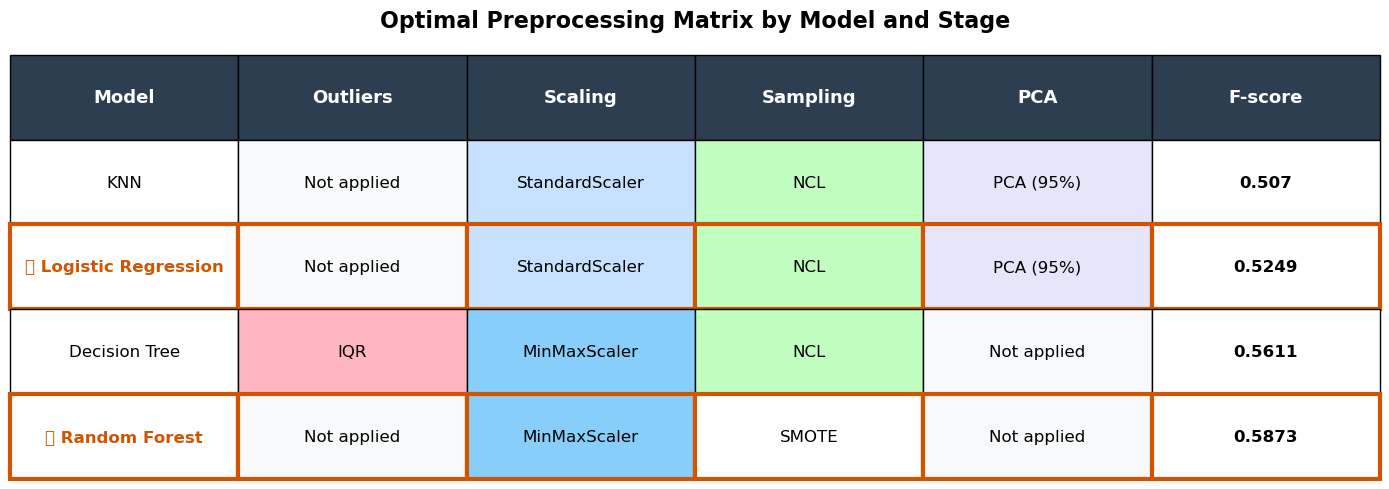

In [10]:
# Extract and format data from phase1_results
rows = []
for model, data in phase1_results.items():
    params = data['best_parameters']
    
    # Helper function to get the clean name of the technique
    def get_name(obj):
        if isinstance(obj, str): return obj
        if hasattr(obj, '__class__') and obj is not None:
            return obj.__class__.__name__
        return str(obj)

    row = {
        'Model': model.replace('_', ' '),
        'Outliers': get_name(params.get('outlier_detector', 'passthrough')),
        'Scaling': get_name(params.get('standardization', 'passthrough')),
        'Sampling': get_name(params.get('sampling', 'passthrough')),
        'PCA': get_name(params.get('pca', 'passthrough')),
        'F-score': round(data['best_fscore'], 4)
    }
    
    # Clean up long names to fit aesthetically in the matrix
    for col in ['Outliers', 'Scaling', 'Sampling', 'PCA']:
        if row[col] == 'passthrough': row[col] = 'Not applied'
        elif 'OutlierDetecion' in row[col]: row[col] = 'IQR'
        elif 'Neighbourhood' in row[col]: row[col] = 'NCL'
        elif 'PCA' in row[col] and col == 'PCA': row[col] = 'PCA (95%)'
        
    rows.append(row)

df_plot = pd.DataFrame(rows)

# Mathematically identify the winners (first 2 are distances, last 2 are trees)
idx_distances = df_plot.iloc[0:2]['F-score'].idxmax()
idx_trees = df_plot.iloc[2:4]['F-score'].idxmax()

# Add 1 because in the visual table row 0 is the header
winning_rows = [idx_distances + 1, idx_trees + 1] 

# Configure colors for the visual matrix (Categorical Heatmap)
technique_colors = {
    'Not applied': '#f8f9fa',    # Very light gray (Almost white)
    'StandardScaler': '#c6e2ff', # Pastel blue
    'MinMaxScaler': '#87cefa',   # Vivid blue
    'NCL': '#c1ffc1',            # Pastel green
    'PCA (95%)': '#e6e6fa',      # Pastel purple
    'IQR': '#ffb6c1'             # Light red/Pink
}

# Draw the matrix using Matplotlib Table
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off') # Remove the axes from the graph

table = ax.table(cellText=df_plot.values,
                 colLabels=df_plot.columns,
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1]) 

# Global table styles
table.auto_set_font_size(False)
table.set_fontsize(12)

# Iterate over the cells to apply formats, colors, and highlight winners
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Header Style
        cell.set_text_props(weight='bold', color='white', fontsize=13)
        cell.set_facecolor('#2c3e50') # Dark slate blue
    else:
        text = cell.get_text().get_text()
        
        # Color the cell background based on the chosen technique
        cell.set_facecolor(technique_colors.get(text, '#ffffff'))
            
        # Bold format for the F-score column
        if col == 5: 
            cell.set_text_props(weight='bold')
            
        # HIGHLIGHT THE WINNERS OF EACH FAMILY
        if row in winning_rows:
            cell.set_edgecolor('#d35400') # Thick copper/gold border
            cell.set_linewidth(3)         # Make the outer line thicker
            
            # Add the trophy to the model name and color it copper
            if col == 0:
                cell.set_text_props(weight='bold', color='#d35400')
                cell.get_text().set_text(f"🏆 {text}")

# Final adjustments
plt.title("Optimal Preprocessing Matrix by Model and Stage", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Phase 2

Warning: It takes less time than phase 1, but it still takes a long time to run.

Starting Phase 2: Calculating the full cross matrix (Swap 4x2)...


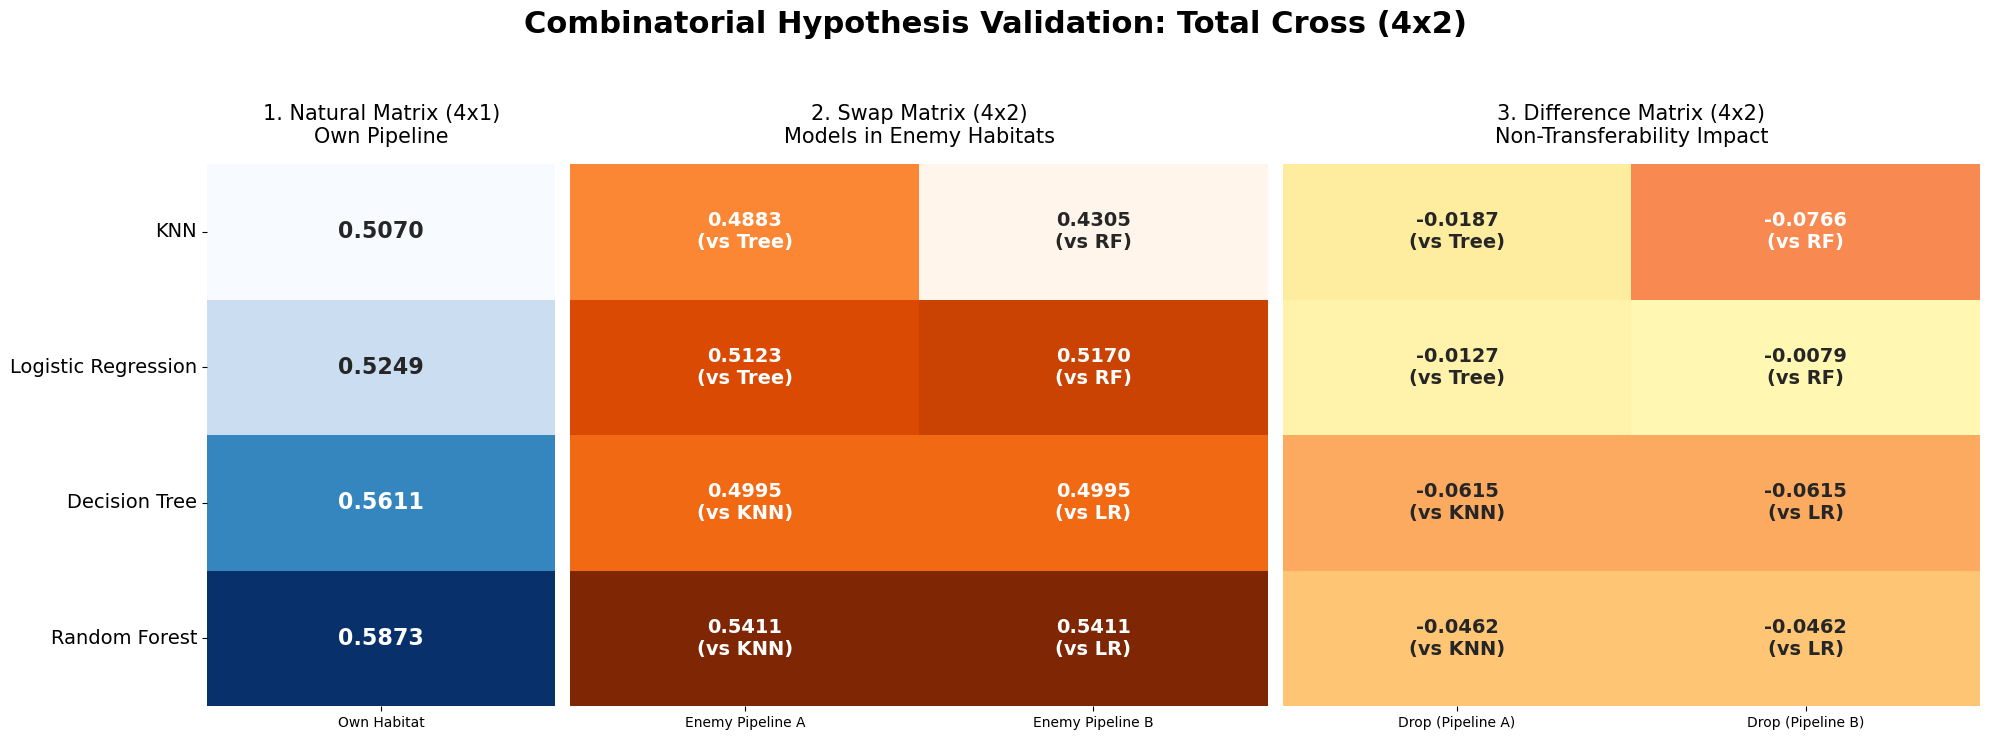

In [11]:


print("Starting Phase 2: Calculating the full cross matrix (Swap 4x2)...")

# Hyperparameters updated to match Phase 1 exactly
grid_only = {
    'KNN': {
        'classifier__n_neighbors': [3, 5],
        'classifier__weights': [ 'distance']
    },
    'Logistic_Regression': {
        'classifier__C': [0.01, 1.0],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000]
    },
    'Decision_Tree': {
        'classifier__max_depth': [5, 20],
        'classifier__min_samples_split': [10, 100],
        'classifier__min_samples_leaf': [20]
    },
    'Random_Forest': {
        'classifier__n_estimators': [300],
        'classifier__max_depth': [5, None],
        'classifier__min_samples_split': [10, 100]
    }
}

bases = {
    'KNN': KNeighborsClassifier(),
    'Logistic_Regression': LogisticRegression(),
    'Decision_Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Random_Forest': RandomForestClassifier(criterion='entropy', random_state=42)
}

def evaluate_swap(enemy_pipe, model, grid):
    swap_pipe = clone(enemy_pipe)
    # We keep the preprocessing from the enemy but change the classifier
    swap_pipe.steps[-1] = ('classifier', model)
    gs = GridSearchCV(swap_pipe, grid, scoring='f1', cv=3, n_jobs=-1) 
    gs.fit(X_train, y_train)
    return gs.best_score_

# Data structures for the matrices
model_names = ['KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest']
natural_scores = []
swap_scores = np.zeros((4, 2))
diff_scores = np.zeros((4, 2))
annot_swap, annot_diff = [], []

dict_names = ['KNN', 'Logistic_Regression', 'Decision_Tree', 'Random_Forest']

for i, model in enumerate(dict_names):
    nat_score = phase1_results[model]['best_fscore']
    natural_scores.append([nat_score])
    
    # Identify the 2 enemy pipelines (habitats)
    if model in ['KNN', 'Logistic_Regression']:
        enemies = [
            ('Tree', phase1_results['Decision_Tree']['best_pipeline']),
            ('RF', phase1_results['Random_Forest']['best_pipeline'])
        ]
    else:
        enemies = [
            ('KNN', phase1_results['KNN']['best_pipeline']),
            ('LR', phase1_results['Logistic_Regression']['best_pipeline'])
        ]
        
    row_swap_annot, row_diff_annot = [], []
    
    # Evaluate model performance in enemy habitats
    for j, (enemy_name, enemy_pipe) in enumerate(enemies):
        swap_score = evaluate_swap(enemy_pipe, bases[model], grid_only[model])
        swap_scores[i, j] = swap_score
        
        diff = swap_score - nat_score
        diff_scores[i, j] = diff
        
        row_swap_annot.append(f"{swap_score:.4f}\n(vs {enemy_name})")
        row_diff_annot.append(f"{diff:.4f}\n(vs {enemy_name})")
        
    annot_swap.append(row_swap_annot)
    annot_diff.append(row_diff_annot)

# Create DataFrames for visualization
df_nat = pd.DataFrame(natural_scores, index=model_names, columns=['Own Habitat'])
df_swap = pd.DataFrame(swap_scores, index=model_names, columns=['Enemy Pipeline A', 'Enemy Pipeline B'])
df_diff = pd.DataFrame(diff_scores, index=model_names, columns=['Drop (Pipeline A)', 'Drop (Pipeline B)'])

# Visual representation of the matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 2, 2]})

sns.heatmap(df_nat, annot=True, fmt=".4f", cmap="Blues", ax=axes[0], cbar=False, 
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("1. Natural Matrix (4x1)\nOwn Pipeline", fontsize=15, pad=15)
axes[0].tick_params(axis='y', labelsize=14, rotation=0)

sns.heatmap(df_swap, annot=np.array(annot_swap), fmt="", cmap="Oranges", ax=axes[1], cbar=False, 
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("2. Swap Matrix (4x2)\nModels in Enemy Habitats", fontsize=15, pad=15)
axes[1].set_yticks([])

sns.heatmap(df_diff, annot=np.array(annot_diff), fmt="", cmap="RdYlGn", center=0, vmax=0, vmin=-0.15, 
            ax=axes[2], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[2].set_title("3. Difference Matrix (4x2)\nNon-Transferability Impact", fontsize=15, pad=15)
axes[2].set_yticks([])

plt.suptitle("Combinatorial Hypothesis Validation: Total Cross (4x2)", fontsize=22, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

## SHAP values

Calculating SHAP values (may take a few seconds)...
Calculation finished! Generating plots...


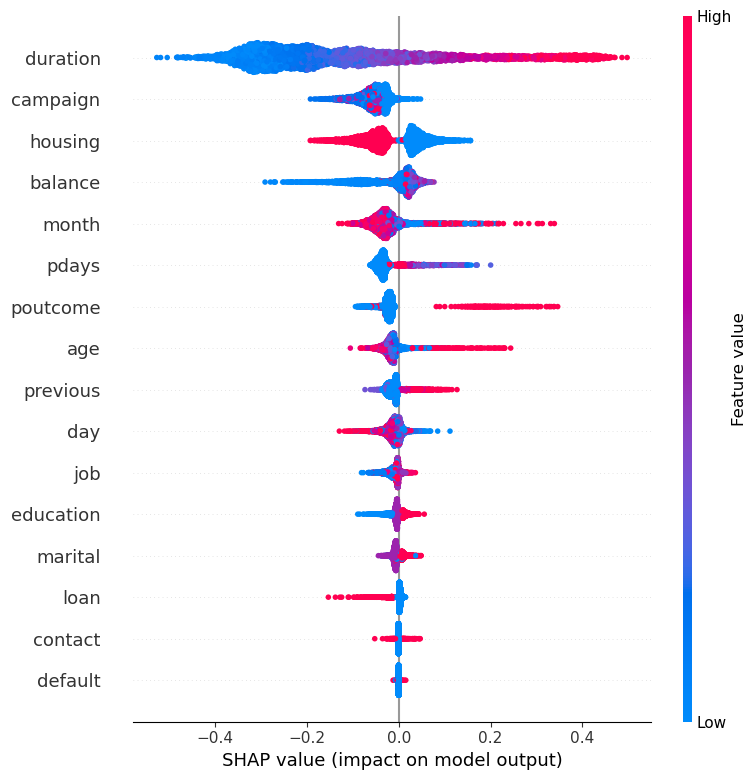

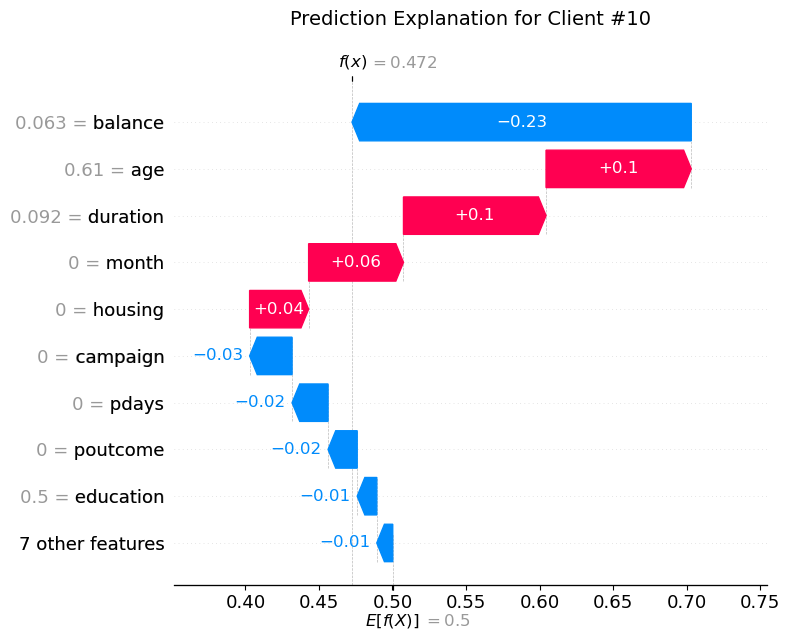

In [ ]:
# Extract the winning Random Forest pipeline
pipe_rf = phase1_results["Random_Forest"]['best_pipeline']

# Separate the preprocessing from the classifier model
transformer_rf = pipe_rf[:-1]
model_rf = pipe_rf.named_steps['classifier']

# Transform the validation data
X_val_transformed = transformer_rf.transform(X_val)

# Extraction of feature names
feature_names = []
try:
    # We go directly to the "heart" that creates the columns: the ColumnTransformer
    preprocessor = pipe_rf.named_steps['preprocessor']
    
    for trans_name, transformer, columns in preprocessor.transformers_:
        if trans_name == 'remainder':
            continue
            
        try:
            # If the transformer is a Pipeline
            if hasattr(transformer, 'steps'):
                last_step = transformer.steps[-1][1]
                if hasattr(last_step, 'get_feature_names_out'):
                    names = last_step.get_feature_names_out(columns)
                else:
                    names = columns
            # If it is a simple transformer
            else:
                if hasattr(transformer, 'get_feature_names_out'):
                    names = transformer.get_feature_names_out(columns)
                else:
                    names = columns
                    
            feature_names.extend(names)
        except:
            # If an internal step fails, we keep the original names
            feature_names.extend(columns)
            
    feature_names = [str(name).split('__')[-1] for name in feature_names]
    
except Exception as e:
    print("Warning: Using contingency plan for names.")
    feature_names = [f"Var_{i}" for i in range(X_val_transformed.shape[1])]

# If the extracted names don't match the actual columns, we use generic ones
if len(feature_names) != X_val_transformed.shape[1]:
    feature_names = [f"Variable_{i}" for i in range(X_val_transformed.shape[1])]

# We convert the array to a DataFrame so SHAP can read the names
X_val_shap = pd.DataFrame(X_val_transformed, columns=feature_names)


# 5. INSTANTIATE SHAP (TreeExplainer)
print("Calculating SHAP values (may take a few seconds)...")
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_val_shap)

# SHAP version compatibility for binary classification
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

print("Calculation finished! Generating plots...")

# PLOT 1: Global Summary (Summary Plot)

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (SHAP Summary Plot) - Random Forest", fontsize=14, pad=20)
shap.summary_plot(shap_values_positive, X_val_shap, show=False)
plt.tight_layout()
plt.show()

# PLOT 2: Local Explanation (Waterfall Plot) 
client_index = 10

# We create the Explanation object required by modern versions of SHAP
expl_obj = shap.Explanation(
    values=shap_values_positive[client_index], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    data=X_val_shap.iloc[client_index].values, 
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
plt.title(f"Prediction Explanation for Client #{client_index}", fontsize=14, pad=20)
shap.waterfall_plot(expl_obj, show=False)
plt.tight_layout()
plt.show()


Calculating Partial Dependence Plots (this may take a while)...


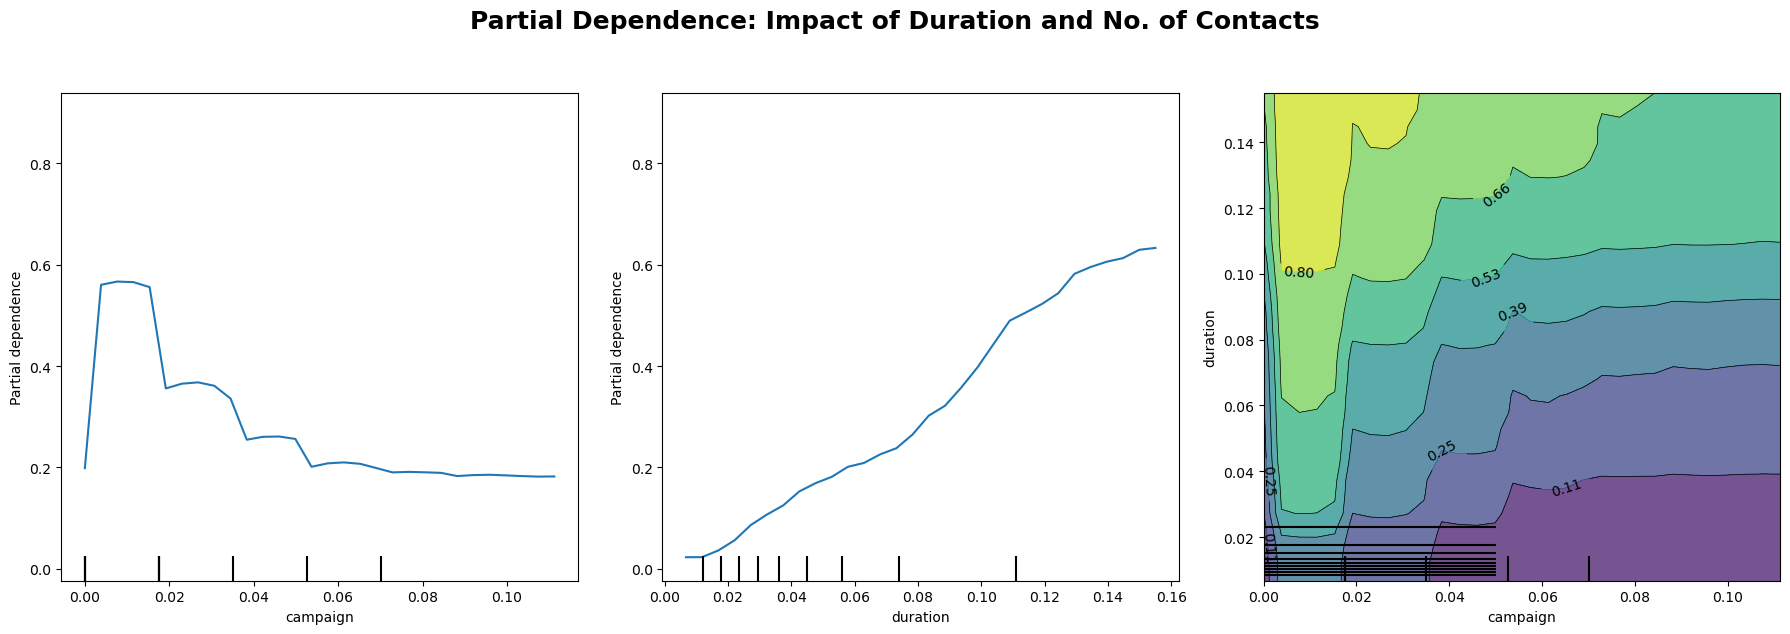

In [13]:
import matplotlib.pyplot as plt

print("Calculating Partial Dependence Plots (this may take a while)...")

# Create the canvas with 3 columns
fig, ax = plt.subplots(ncols=3, figsize=(18, 6))

# Generate the plots using our isolated model and the transformed data
PartialDependenceDisplay.from_estimator(
    estimator=model_rf,           # The isolated Random Forest classifier
    X=X_val_shap,                 # The validation data already processed and with names
    features=['campaign', 'duration', ['campaign', 'duration']], # Variables to analyze
    grid_resolution=30,           # Grid resolution
    target=1,                     # Target the positive class (Accepts the deposit = 1)
    ax=ax,                        # Pass the axes we have created
    n_jobs=-1                     # Parallelize for more speed
)

# Aesthetic adjustments to look perfect in the report
fig.suptitle("Partial Dependence: Impact of Duration and No. of Contacts", 
             fontsize=18, weight='bold', y=1.05)

# Individual titles for each subplot for greater clarity

plt.tight_layout()
plt.show()
